# LeetCode #429: N-ary Tree Level Order Traversal

https://leetcode.com/problems/n-ary-tree-level-order-traversal/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (DFS + sort by depth)** | $O(n)$ | $O(n)$ |
| **BFS (Queue)** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (DFS + sort by depth)
Recursively traverse the tree, pairing each node's value with its depth, then group all values by depth. Works but requires a full pass plus a grouping phase; the sort-by-depth framing is unnatural and produces the same asymptotic cost without the clean level-at-a-time control BFS gives.

### Optimal: BFS (Queue) ★
Process the tree level by level using a queue. Seed the queue with the root, then repeatedly drain the queue one level at a time: record the current queue size, pop that many nodes, collect their values into a level list, and enqueue all their children. Append each completed level list to the result.

**Why this is better than Brute Force:** BFS naturally produces one list per level in a single pass with no depth bookkeeping or post-processing grouping step.

**Constraints:**
* The total number of nodes is in the range [0, 10^4]
* The depth of the n-ary tree is at most 1000
* Node values are in the range [1, 10^4]

## Solutions

### C#

In [ ]:
/*
// Definition for a Node.
public class Node {
    public int val;
    public IList<Node> children;
    public Node() {}
    public Node(int _val) { val = _val; }
    public Node(int _val, IList<Node> _children) { val = _val; children = _children; }
}
*/

public class Solution {
    public IList<IList<int>> LevelOrder(Node root) {
        var result = new List<IList<int>>();
        if (root == null) return result;

        var queue = new Queue<Node>();
        queue.Enqueue(root);

        while (queue.Count > 0) {
            int levelSize = queue.Count;
            var level = new List<int>(levelSize);
            // Drain exactly one level at a time
            for (int i = 0; i < levelSize; i++) {
                var node = queue.Dequeue();
                level.Add(node.val);
                foreach (var child in node.children)
                    queue.Enqueue(child);
            }
            result.Add(level);
        }
        return result;
    }
}

### Python

In [ ]:
from collections import deque
from typing import Optional

class Node:
    def __init__(self, val=None, children=None):
        self.val = val
        self.children = children if children is not None else []

class Solution:
    def levelOrder(self, root: Optional[Node]) -> list[list[int]]:
        if not root:
            return []
        result = []
        queue = deque([root])
        while queue:
            level_size = len(queue)
            level = []
            # Drain exactly one level at a time
            for _ in range(level_size):
                node = queue.popleft()
                level.append(node.val)
                queue.extend(node.children)
            result.append(level)
        return result

### Go

In [ ]:
/**
 * Definition for a Node.
 * type Node struct {
 *     Val int
 *     Children []*Node
 * }
 */

func levelOrder(root *Node) [][]int {
    if root == nil {
        return nil
    }
    result := [][]int{}
    queue := []*Node{root}
    for len(queue) > 0 {
        levelSize := len(queue)
        level := make([]int, 0, levelSize)
        // Drain exactly one level at a time
        for i := 0; i < levelSize; i++ {
            node := queue[0]
            queue = queue[1:]
            level = append(level, node.Val)
            queue = append(queue, node.Children...)
        }
        result = append(result, level)
    }
    return result
}

### Rust

In [ ]:
use std::collections::VecDeque;
use std::rc::Rc;
use std::cell::RefCell;

// Definition for a Node.
// pub struct Node {
//     pub val: i32,
//     pub children: Vec<Option<Rc<RefCell<Node>>>>,
// }

impl Solution {
    pub fn level_order(root: Option<Rc<RefCell<Node>>>) -> Vec<Vec<i32>> {
        let mut result = Vec::new();
        let root = match root {
            Some(r) => r,
            None => return result,
        };
        let mut queue = VecDeque::new();
        queue.push_back(root);
        while !queue.is_empty() {
            let level_size = queue.len();
            let mut level = Vec::with_capacity(level_size);
            // Drain exactly one level at a time
            for _ in 0..level_size {
                let node = queue.pop_front().unwrap();
                let node = node.borrow();
                level.push(node.val);
                for child in &node.children {
                    if let Some(c) = child {
                        queue.push_back(Rc::clone(c));
                    }
                }
            }
            result.push(level);
        }
        result
    }
}

## Example Scenarios

**1. Common Case**
**Input:** root = [1,null,3,2,4,null,5,6]
Tree: root=1, children=[3,2,4], 3's children=[5,6]. BFS: enqueue 1 → level=[1]. Pop 1, enqueue 3,2,4 → level=[3,2,4]. Pop 3, enqueue 5,6; pop 2, no children; pop 4, no children → level=[5,6]. Result: [[1],[3,2,4],[5,6]].

**2. Slightly Complex**
**Input:** root = [1,null,2,3,4,5,null,null,6,7,null,8,null,9,10,null,null,11,null,12,null,13,null,null,14]
A deeper 4-level tree. Each BFS iteration snapshot-freezes the queue length before the loop, so even nodes with many children don't bleed into the next level's count. Result: [[1],[2,3,4,5],[6,7,8,9,10],[11,12,13,14]].

**3. Edge Case: Time Factor**
**Input:** A chain of $n=10^4$ nodes each with exactly one child (a linked-list tree).
The queue never holds more than 1 node at a time, but the while-loop runs $n$ times — one iteration per level. Total work is $O(n)$ node visits with $O(n)$ queue operations. This is the maximum iteration count possible.

**4. Edge Case: Space Factor**
**Input:** A 2-level tree: root with $10^4 - 1$ children, all leaves.
After the first iteration, all $10^4 - 1$ children are enqueued simultaneously — the queue's peak size equals the widest level. Space is $O(\text{max\_width}) \subseteq O(n)$; this is the worst case for queue memory.

**5. Almost-Impossible but Plausible**
**Input:** root = null
Immediately returns []. The null-guard fires before any queue allocation. No BFS iterations run. This is the degenerate case where $n=0$.

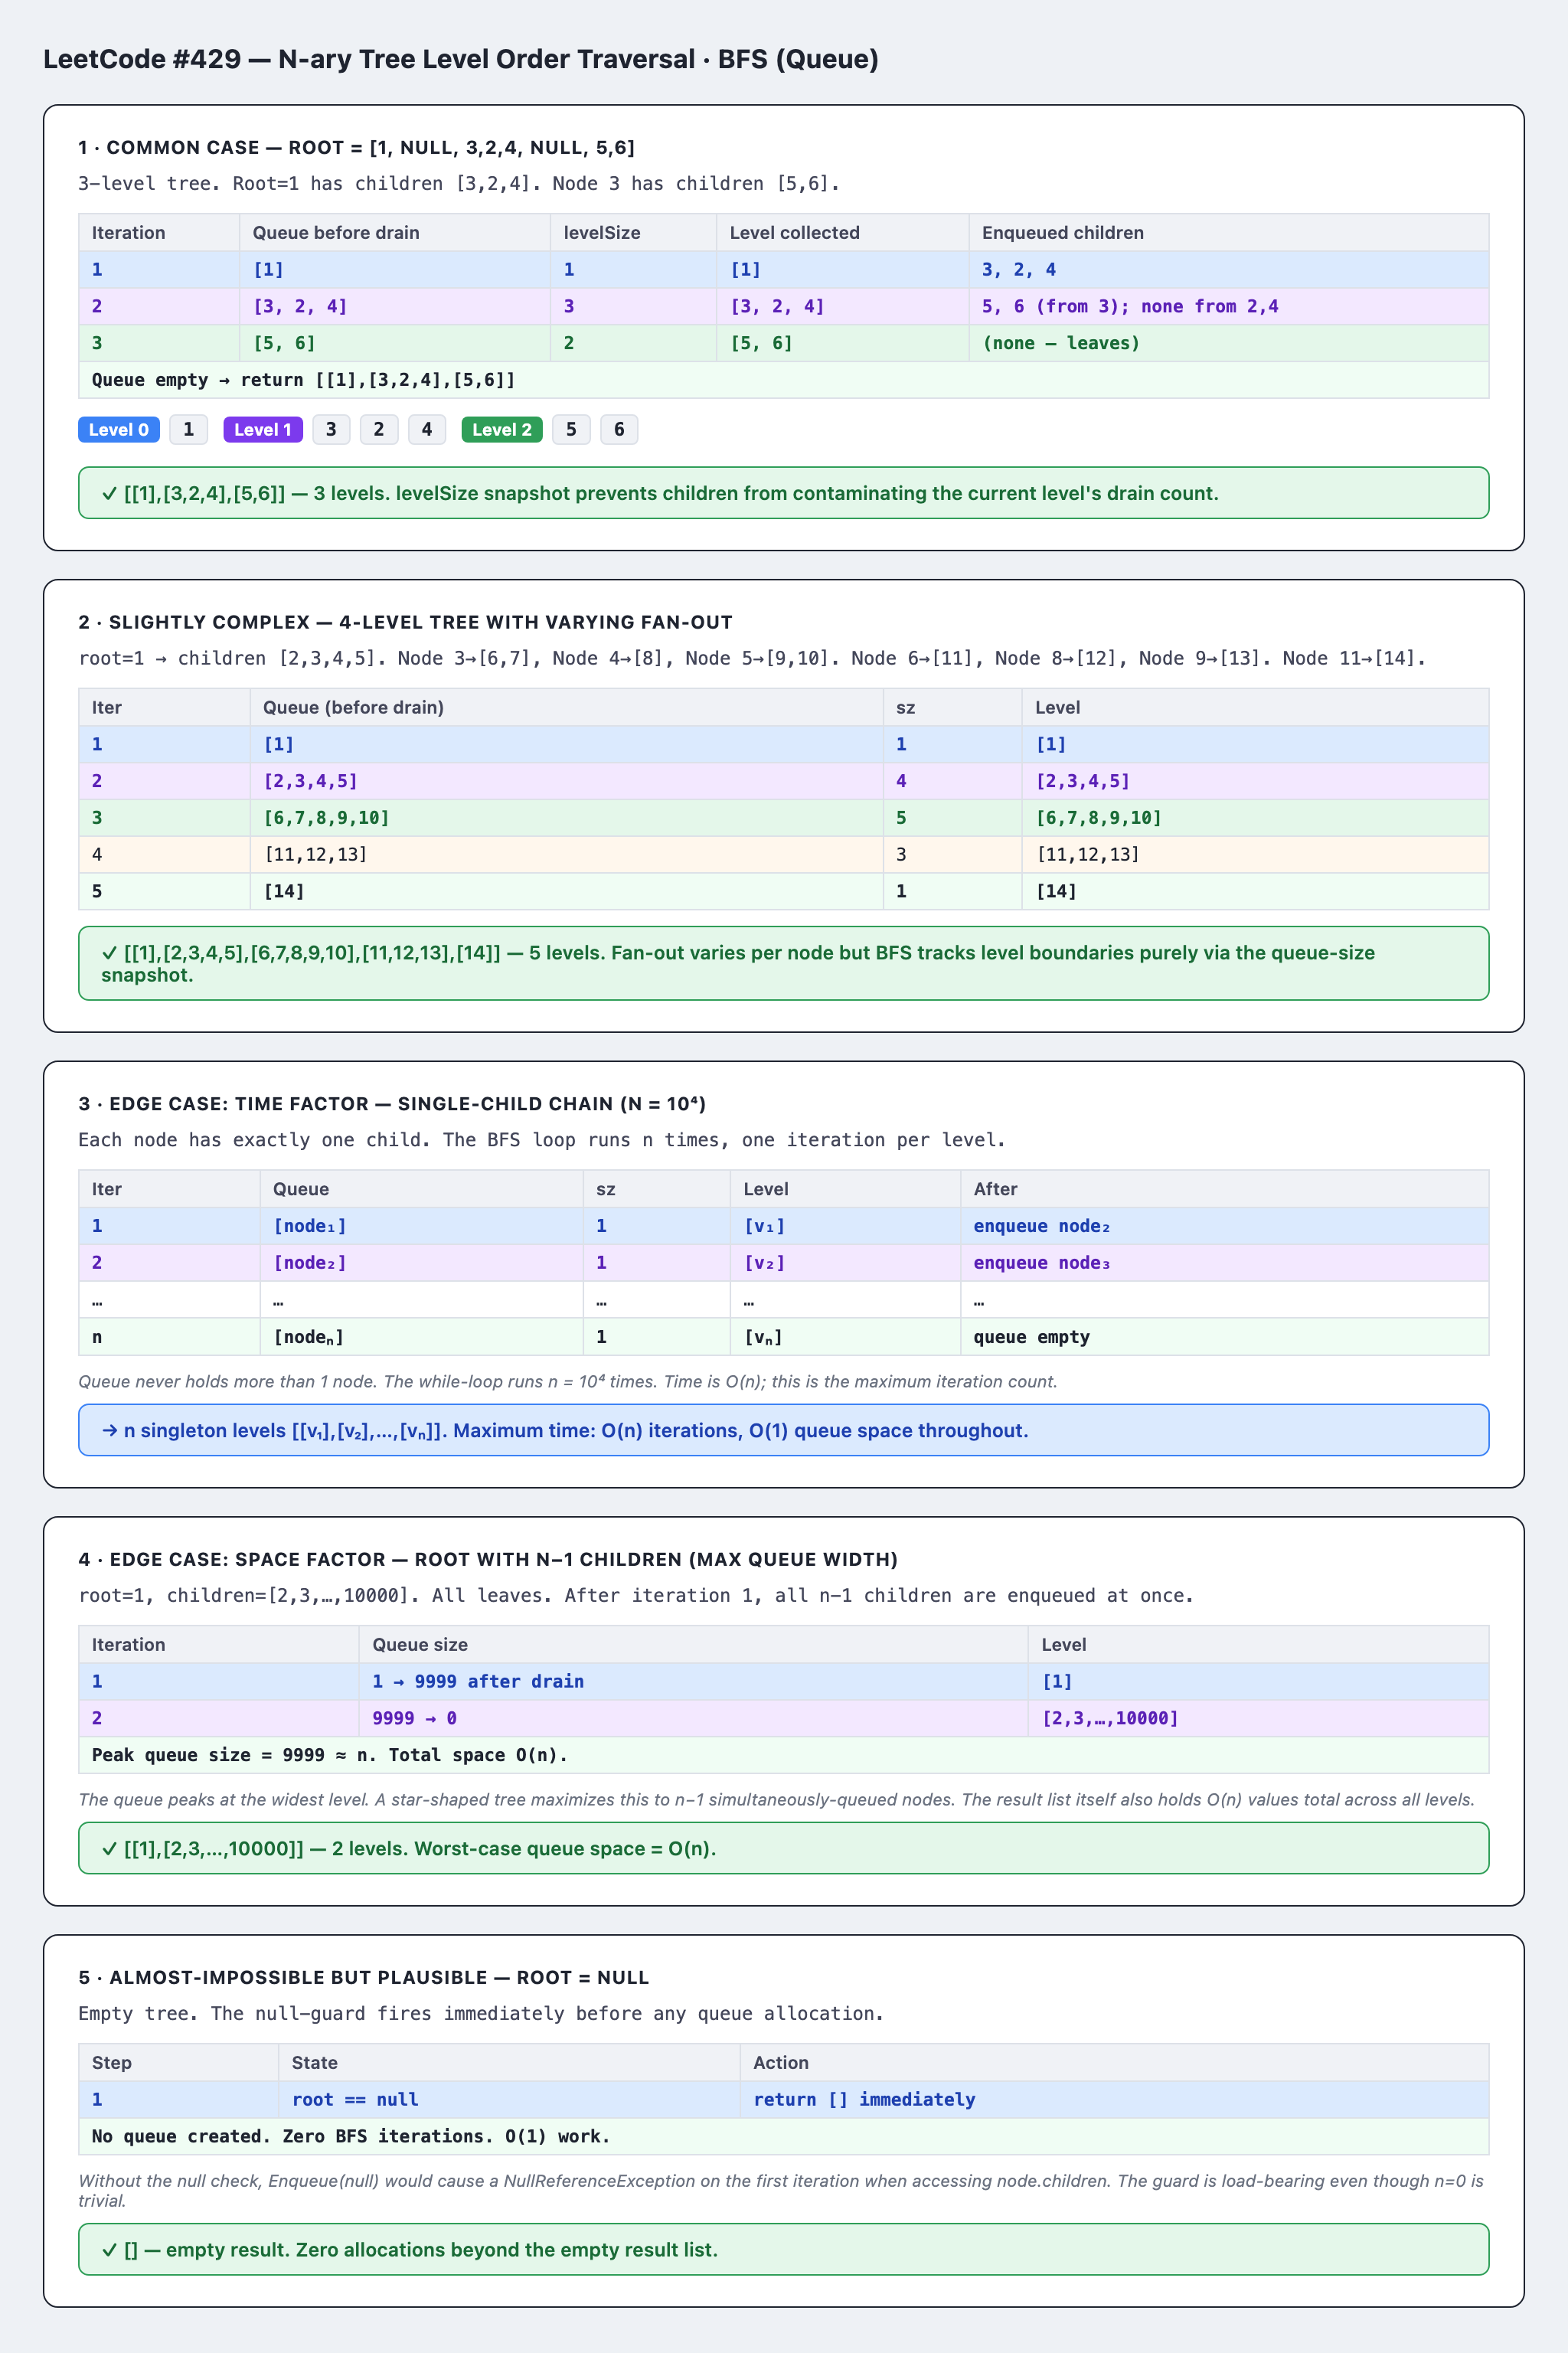